# 03 — Tenure classes + AOI overlays (Gate AB-0a, part iii) — the private-lands ESTIMATE

Kernel `y2y-geo`. **Zero solves; nothing here enters a formulation** (D-AB3: reporting only).
Inputs = the open layers from `data/acquire.py` (provenance in `data/provenance.json`).
Spec v0.4.4 D-AB3 (the equation below), D-AB4 (AOI-2), D-AB6 tabled (distance-to-PA prepared for the
post-hoc reading), D-AB8 on hold (dispositions absent → the estimate is disclosed as contaminated by
crown grazing leases inside the White Area).

## The private-lands estimate equation (per 1 km cell, centre-in-polygon rule)

```
pa_locked          = PA                                            (parent lock-in mask)
crown_green        = ¬PA ∧ GreenArea
crown_white_ind    = ¬PA ∧ WhiteArea ∧ CROWN_IND
private_presumed   = ¬PA ∧ WhiteArea ∧ ¬CROWN_IND
private_ranchland  = private_presumed ∧ ranch_frac ≥ 0.5
   CROWN_IND  = CrownLandReservation(active) ∨ PLUZ ∨ Disposition(if a licensed layer is present)
   ranch_frac = GVI ranchland fraction where GVI exists (native upland site types + tame pasture/hay),
                else AAFC Annual Crop Inventory 2024 fraction of {110 grassland, 122 pasture/forages, 50 shrubland}
```

What the estimate gets wrong, by construction (disclosed in the tenure table): crown land in the
White Area that carries NO reservation/PLUZ notation — chiefly **grazing leases** — is counted as
`private_presumed`, so `private_ranchland` is an OVER-count of private ranchland by the leased share.
At 1 km a cell holds ~1.5 quarter sections, so every class reads "mostly X", never a parcel.

In [4]:
# ---- bootstrap -------------------------------------------------------------------------------------
import importlib, json, pathlib, subprocess, sys, shutil, warnings
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import geopandas as gpd
import pyogrio
import rasterio
from rasterio.features import rasterize
from rasterio.windows import Window, transform as win_transform
from rasterio.warp import transform_bounds
from affine import Affine
warnings.filterwarnings("ignore")

_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.py").exists()]
assert _cands, "config.py not found above the notebook"
ROOT = _cands[0]
sys.path.insert(0, str(ROOT))
import config, leverage_core as lc
importlib.reload(config); importlib.reload(lc)

HERE = ROOT / "analyses" / "alberta_prioritization"
SPEC, FIGS, DATA = HERE / "spec", HERE / "figures", HERE / "data"
DERIVED, C4 = DATA / "derived", HERE / "analysis" / "c4_aoi"
for _d in (FIGS, DERIVED, C4):
    _d.mkdir(parents=True, exist_ok=True)
AB = config.AB_HANDOFF_DIR
CRS = config.TARGET_CRS
EXTENT = json.loads((SPEC / "ab_extent_v1.json").read_text())

with rasterio.open(AB / "cost_uniform.tif") as src:
    T, H, W = src.transform, src.height, src.width
    AB_PU = np.isfinite(src.read(1, masked=True).filled(np.nan))
with rasterio.open(AB / "mask_protected_areas.tif") as src:
    PA_AB = (src.read(1) == 1) & AB_PU
with rasterio.open(config.HANDOFF_DIR / "mask_protected_areas.tif") as src:
    PA_ALL = src.read(1) == 1                       # parent-wide lock (BC parks count for distance)
assert int(AB_PU.sum()) == EXTENT["n_pu"] and int(PA_AB.sum()) == EXTENT["n_locked"]
DISC = AB_PU & ~PA_AB

# AB window (+2 km margin) for the fine-resolution work
rows, cols = np.where(AB_PU.any(axis=1))[0], np.where(AB_PU.any(axis=0))[0]
R0, R1, C0, C1 = max(rows.min() - 2, 0), min(rows.max() + 3, H), max(cols.min() - 2, 0), min(cols.max() + 3, W)
WIN = Window(C0, R0, C1 - C0, R1 - R0)
T_WIN = win_transform(WIN, T)
WH, WW = R1 - R0, C1 - C0
x0, y0 = T_WIN.c, T_WIN.f
WIN_BOUNDS = (x0, y0 - WH * 1000, x0 + WW * 1000, y0)      # left, bottom, right, top (102008)

FILES = dict(gw=DATA / "tenure" / "green_white_area.gpkg", pluz=DATA / "pa" / "pluz.gpkg",
             res="/vsizip/" + str(DATA / "tenure" / "CrownlandReservations_SHP.zip") + "/Data/CrownLandReservations.shp",
             gvi=DATA / "tenure" / "GrasslandVegetationInventory" / "Data" / "GrasslandVegetationInventory.gdb",
             aci="/vsizip/" + str(DATA / "tenure" / "aci_2024_ab_v2.zip") + "/aci_2024_ab_v2.tif",
             nfz="/vsizip/" + str(DATA / "aoi" / "US_SRP_Zones.zip") + "/Data/US_SRP_Zones.shp",
             srp_pa="/vsizip/" + str(DATA / "aoi" / "US_SRP_ConservationAreasParks.zip") + "/Data/US_SRP_Conservation_Areas_and_Parks.shp",
             srp_bnd="/vsizip/" + str(DATA / "aoi" / "US_SRP_PlanningBoundary.zip") + "/Data/US_SRP_PlanningBoundary.shp",
             dids=DATA / "tenure" / "dids_dispositions.gpkg")
for k in ("gw", "pluz", "gvi"):
    assert pathlib.Path(FILES[k]).exists(), f"{k} missing -- run data/acquire.py (and unzip GVI) first"
assert shutil.which("gdalwarp"), "gdalwarp not on PATH"
HAVE_DIDS = pathlib.Path(FILES["dids"]).exists()
print(f"AB PU {AB_PU.sum():,} | locked {PA_AB.sum():,} | discretionary {DISC.sum():,} | window {WH}x{WW} cells")
print(f"dispositions layer: {'PRESENT' if HAVE_DIDS else 'ABSENT (D-AB8 on hold) -- estimate contaminated by crown leases, disclosed'}")

AB PU 85,133 | locked 27,972 | discretionary 57,161 | window 854x320 cells
dispositions layer: ABSENT (D-AB8 on hold) -- estimate contaminated by crown leases, disclosed


## 1. Vector layers → 1 km indicators (centre-in-polygon, same rule as the parent PA mask)

In [5]:
# ---- rasterize helpers on the FULL parent grid ------------------------------------------------------
def burn(gdf, value=1, dtype="uint8"):
    g = gdf.to_crs(CRS)
    g = g[~g.geometry.is_empty & g.geometry.notna()]
    return rasterize([(geom, value) for geom in g.geometry], out_shape=(H, W), transform=T,
                     fill=0, all_touched=False, dtype=dtype).astype(bool)

gw = gpd.read_file(FILES["gw"])
GREEN = burn(gw[gw.GWA_NAME == "Green Area"])
WHITE = burn(gw[gw.GWA_NAME == "White Area"])
res = gpd.read_file(FILES["res"])
res = res[res.StatusCode == "ACTIVE"]
RESERVED = burn(res)
pluz = gpd.read_file(FILES["pluz"])
PLUZ = burn(pluz)
DIDS = burn(gpd.read_file(FILES["dids"])) if HAVE_DIDS else np.zeros((H, W), bool)
CROWN_IND = RESERVED | PLUZ | DIDS

n = AB_PU.sum()
print(f"{'indicator':<22}{'AB cells':>10}{'% extent':>10}{'of which PA':>13}")
for k, m in (("Green Area", GREEN), ("White Area", WHITE), ("reservation (active)", RESERVED),
             ("PLUZ", PLUZ), ("dispositions", DIDS), ("CROWN_IND (any)", CROWN_IND)):
    print(f"{k:<22}{int((m & AB_PU).sum()):10,}{100*(m & AB_PU).sum()/n:10.1f}{int((m & PA_AB).sum()):13,}")
neither = AB_PU & ~GREEN & ~WHITE
print(f"\nAB cells in NEITHER Green nor White (outside the provincial layer, e.g. federal/reserve/park gaps): "
      f"{int(neither.sum()):,} ({100*neither.sum()/n:.2f}%) -- classed by PA if locked, else 'unclassified'")
print(f"reservations inside the WHITE Area (the crown indicator that matters): {int((RESERVED & WHITE & AB_PU & ~PA_AB).sum()):,} discretionary cells")

indicator               AB cells  % extent  of which PA
Green Area                58,698      68.9       10,982
White Area                 9,532      11.2          204
reservation (active)      35,616      41.8        7,093
PLUZ                      10,744      12.6          361
dispositions                   0       0.0            0
CROWN_IND (any)           35,835      42.1        7,097

AB cells in NEITHER Green nor White (outside the provincial layer, e.g. federal/reserve/park gaps): 16,903 (19.85%) -- classed by PA if locked, else 'unclassified'
reservations inside the WHITE Area (the crown indicator that matters): 1,992 discretionary cells


## 2. Ranchland cover fraction — GVI where it exists, AAFC ACI 2024 elsewhere

GVI: per landscape polygon, ranch_frac = Σ PCT_OF_POLYGON over ranchland site types ÷ 100
(native upland: Loamy, Thin Breaks, Overflow, Limy, Blowouts/Solonetzic, Subirrigated, Sandy,
Saline Lowland, Sand, Clayey, Badlands/Bedrock, Shallow to Gravel, Choppy Sandhills, Gravel; plus
Tame Pasture or Hay, irrigated and non-irrigated). Rasterised at 100 m, block-averaged to 1 km.
ACI: 30 m classes {110, 122, 50} → binary → `gdalwarp -r average` onto the AB grid. The seam
(GVI's northern limit ≈ 52.5°N) is reported.

In [6]:
# ---- GVI ranch fraction (100 m rasterize -> 1 km block mean) -----------------------------------------
RANCH_TYPES = {"Loamy", "Thin Breaks", "Overflow", "Limy", "Blowouts/Solonetzic", "Subirrigated", "Sandy",
               "Saline Lowland", "Sand", "Clayey", "Badlands/Bedrock", "Shallow to Gravel", "Choppy Sandhills",
               "Gravel", "Tame Pasture or Hay (Non-irrigated)", "Tame Pasture or Hay (Irrigated)"}
bbox3400 = gpd.GeoSeries([__import__("shapely").geometry.box(*WIN_BOUNDS)], crs=CRS).to_crs("EPSG:3400").total_bounds
polys = pyogrio.read_dataframe(FILES["gvi"], layer="LANDSCAPE_POLYGONS", columns=["GLOBALID"], bbox=tuple(bbox3400))
# SITE_TYPE is a coded domain (1-32) in the SITES table; the SitesView resolves it to names.
sites = pyogrio.read_dataframe(FILES["gvi"], layer="GrasslandVegetationInventorySitesView", read_geometry=False,
                               columns=["LANDSCAPE_POLYGON_GUID", "SITE_TYPE", "PCT_OF_POLYGON"])
sites = sites[sites.LANDSCAPE_POLYGON_GUID.isin(set(polys.GLOBALID))]
unknown = set(sites.SITE_TYPE.dropna()) - RANCH_TYPES - {
    "Lentic (Open Water)", "Lentic (Seasonal)", "Lentic (Temporary)", "Lentic (Semi-Permanent to Permanent)", "Lentic (Alkali)",
    "Lotic (Herbaceous)", "Lotic (Shrub)", "Lotic (Deciduous)", "Lotic (Coniferous)", "Lotic (River)",
    "Crop (Non-irrigated)", "Crop (Irrigated)", "Rural", "Developed", "Urban", "Pits"}
assert not unknown, f"unclassified GVI site types (add to the lists): {unknown}"
rf = (sites.assign(r=sites.SITE_TYPE.isin(RANCH_TYPES) * sites.PCT_OF_POLYGON.fillna(0) / 100.0)
           .groupby("LANDSCAPE_POLYGON_GUID").r.sum().clip(0, 1))
polys = polys.merge(rf.rename("ranch_frac"), left_on="GLOBALID", right_index=True, how="left").fillna({"ranch_frac": 0.0})
polys = polys.to_crs(CRS)
print(f"GVI in the AB window: {len(polys):,} landscape polygons, {len(sites):,} sites; mean polygon ranch_frac {polys.ranch_frac.mean():.3f}")

T100 = Affine(100.0, 0.0, x0, 0.0, -100.0, y0)
shape100 = (WH * 10, WW * 10)
g100 = rasterize([(geom, v) for geom, v in zip(polys.geometry, polys.ranch_frac)], out_shape=shape100,
                 transform=T100, fill=np.nan, all_touched=False, dtype="float32")
GVI_COV_W = (~np.isnan(g100)).reshape(WH, 10, WW, 10).mean(axis=(1, 3))       # share of the 1 km cell covered by GVI
GVI_RF_W = np.nanmean(np.where(np.isnan(g100), np.nan, g100).reshape(WH, 10, WW, 10), axis=(1, 3))
GVI_RF_W = np.nan_to_num(GVI_RF_W, nan=0.0)

GVI in the AB window: 121,970 landscape polygons, 232,523 sites; mean polygon ranch_frac 0.608


In [7]:
# ---- ACI 2024 ranch fraction (30 m binary -> gdalwarp average -> AB window grid) ----------------------
ACI_RANCH = {110, 122, 50}         # grassland, pasture/forages, shrubland
mask30 = DERIVED / "_aci_ranch_mask_30m.tif"
rf_aci = DERIVED / "ranch_frac_aci_1km.tif"
if not rf_aci.exists():
    with rasterio.open(FILES["aci"]) as src:
        b = transform_bounds(CRS, src.crs, *WIN_BOUNDS, densify_pts=21)
        win = rasterio.windows.from_bounds(*b, transform=src.transform).round_offsets().round_lengths()
        win = win.intersection(Window(0, 0, src.width, src.height))
        prof = dict(driver="GTiff", width=int(win.width), height=int(win.height), count=1, dtype="uint8",
                    crs=src.crs, transform=win_transform(win, src.transform), nodata=255,
                    compress="DEFLATE", tiled=True)
        seen = {}
        with rasterio.open(mask30, "w", **prof) as dst:
            step = 2048
            for r in range(0, int(win.height), step):
                h = min(step, int(win.height) - r)
                sub = Window(win.col_off, win.row_off + r, win.width, h)
                a = src.read(1, window=sub)
                u, c = np.unique(a, return_counts=True)
                for k, v in zip(u, c): seen[int(k)] = seen.get(int(k), 0) + int(v)
                out = np.isin(a, list(ACI_RANCH)).astype("uint8")
                out[a == 0] = 255                                   # 0 = ACI nodata/unclassified
                dst.write(out, 1, window=Window(0, r, win.width, h))
    top = sorted(seen.items(), key=lambda kv: -kv[1])[:12]
    print("ACI classes in the AB window (top 12):", top)
    assert 110 in seen and 122 in seen, "expected ACI grassland/pasture classes absent -- check the legend"
    cmd = ["gdalwarp", "-overwrite", "-t_srs", CRS, "-te", *map(str, WIN_BOUNDS), "-tr", "1000", "1000",
           "-r", "average", "-ot", "Float32", "-dstnodata", "nan", "-of", "GTiff", "-co", "COMPRESS=DEFLATE",
           str(mask30), str(rf_aci)]
    proc = subprocess.run(cmd, capture_output=True, text=True)
    if proc.returncode != 0:
        raise RuntimeError(proc.stderr)
    print("wrote", rf_aci.relative_to(ROOT))
with rasterio.open(rf_aci) as s:
    ACI_RF_W = np.nan_to_num(s.read(1), nan=0.0)
    assert s.width == WW and s.height == WH, "ACI warp did not land on the AB window grid"

# ---- combine on the full grid: GVI where it covers the cell (>= 0.5), ACI elsewhere ----------------------
RANCH_FRAC = np.full((H, W), np.nan, "float32"); GVI_COV = np.zeros((H, W), bool)
gvi_here = GVI_COV_W >= 0.5
RANCH_FRAC[R0:R1, C0:C1] = np.where(gvi_here, GVI_RF_W, ACI_RF_W)
GVI_COV[R0:R1, C0:C1] = gvi_here
RANCH_FRAC[~AB_PU] = np.nan
lat = gpd.GeoSeries(gpd.points_from_xy([x0], [y0 - (np.where(GVI_COV.any(axis=1))[0].min() - R0) * 1000]), crs=CRS).to_crs(4326).y[0] if GVI_COV.any() else float("nan")
print(f"GVI covers {int((GVI_COV & AB_PU).sum()):,} AB cells ({100*(GVI_COV & AB_PU).sum()/AB_PU.sum():.1f}%); "
      f"northern GVI limit in the extent ≈ {lat:.2f}°N; ACI elsewhere")
print(f"ranch_frac mean over discretionary cells: GVI-covered {np.nanmean(RANCH_FRAC[DISC & GVI_COV]):.3f} | ACI-covered {np.nanmean(RANCH_FRAC[DISC & ~GVI_COV]):.3f}")

def write_grid(path, arr, nodata, dtype):
    prof = dict(driver="GTiff", width=W, height=H, count=1, dtype=dtype, crs=CRS, transform=T, nodata=nodata,
                compress="DEFLATE", tiled=True)
    with rasterio.open(path, "w", **prof) as dst:
        dst.write(np.asarray(arr).astype(dtype), 1)
write_grid(DERIVED / "ranch_frac.tif", RANCH_FRAC, np.nan, "float32")
write_grid(DERIVED / "gvi_coverage.tif", np.where(AB_PU, GVI_COV, 255), 255, "uint8")

ACI classes in the AB window (top 12): [(0, 114874082), (210, 78127913), (220, 35184758), (30, 15490083), (122, 10945169), (80, 10079955), (110, 9257978), (146, 8558695), (50, 8117629), (153, 7264914), (133, 6961453), (34, 4085838)]
wrote analyses/alberta_prioritization/data/derived/ranch_frac_aci_1km.tif
GVI covers 6,949 AB cells (8.2%); northern GVI limit in the extent ≈ 51.40°N; ACI elsewhere
ranch_frac mean over discretionary cells: GVI-covered 0.884 | ACI-covered 0.067


## 3. The tenure classification (the equation, applied)

Codes in `tenure_class.tif`: 1 `pa_locked` · 2 `crown_green` · 3 `crown_white_ind` · 4 `private_presumed`
(non-ranch) · 5 `private_ranchland` · 6 unclassified (in neither provincial area) · 255 outside the PU.

In [8]:
# ---- classify ------------------------------------------------------------------------------------------
RF = np.nan_to_num(RANCH_FRAC, nan=0.0)
cls = np.full((H, W), 255, "uint8")
cls[AB_PU] = 6
cls[AB_PU & ~PA_AB & GREEN] = 2
cls[AB_PU & ~PA_AB & WHITE & CROWN_IND] = 3
priv = AB_PU & ~PA_AB & WHITE & ~CROWN_IND
cls[priv] = 4
cls[priv & (RF >= 0.5)] = 5
cls[PA_AB] = 1
NAMES = {1: "pa_locked", 2: "crown_green", 3: "crown_white_ind", 4: "private_presumed (non-ranch)",
         5: "private_ranchland", 6: "unclassified (neither Green nor White)"}
rows = []
for k, nm in NAMES.items():
    m = cls == k
    rows.append(dict(code=k, tenure_class=nm, cells=int(m.sum()), km2=int(m.sum()),
                     pct_extent=round(100 * m.sum() / AB_PU.sum(), 2),
                     pct_discretionary=round(100 * (m & DISC).sum() / DISC.sum(), 2) if k != 1 else 0.0))
TEN = pd.DataFrame(rows)
print(TEN.to_string(index=False))
print(f"\nOECM-track pool (private_ranchland) = {int((cls==5).sum()):,} km² = {100*(cls==5).sum()/DISC.sum():.1f}% of discretionary land")
print(f"protection-track pool (crown_green + crown_white_ind) = {int(((cls==2)|(cls==3)).sum()):,} km² = "
      f"{100*((cls==2)|(cls==3)).sum()/DISC.sum():.1f}% of discretionary land")
sens = {th: int((priv & (RF >= th)).sum()) for th in (0.3, 0.5, 0.7)}
print("private_ranchland sensitivity to the ranch_frac threshold (km²):", sens)
print("DISCLOSURE: private_presumed/private_ranchland include crown grazing leases inside the White Area "
      "(no disposition layer, D-AB8 on hold) -> both are OVER-counts of private land by the leased share.")
write_grid(DERIVED / "tenure_class.tif", cls, 255, "uint8")
TEN.to_csv(SPEC / "tenure_shares_v1.csv", index=False)
(SPEC / "tenure_shares_v1.json").write_text(json.dumps(dict(
    created_utc=datetime.now(timezone.utc).isoformat(), equation="spec v0.4.4 D-AB3", dispositions_present=HAVE_DIDS,
    ranch_frac_threshold=0.5, ranch_frac_sensitivity_km2=sens, gvi_covered_cells=int((GVI_COV & AB_PU).sum()),
    classes={r.tenure_class: dict(code=int(r.code), km2=int(r.km2), pct_extent=r.pct_extent, pct_discretionary=r.pct_discretionary)
             for r in TEN.itertuples()}), indent=1))
print("wrote data/derived/tenure_class.tif + spec/tenure_shares_v1.{csv,json}")

 code                           tenure_class  cells   km2  pct_extent  pct_discretionary
    1                              pa_locked  27972 27972       32.86               0.00
    2                            crown_green  47716 47716       56.05              83.48
    3                        crown_white_ind   1992  1992        2.34               3.48
    4           private_presumed (non-ranch)   1943  1943        2.28               3.40
    5                      private_ranchland   5393  5393        6.33               9.43
    6 unclassified (neither Green nor White)    117   117        0.14               0.20

OECM-track pool (private_ranchland) = 5,393 km² = 9.4% of discretionary land
protection-track pool (crown_green + crown_white_ind) = 49,708 km² = 87.0% of discretionary land
private_ranchland sensitivity to the ranch_frac threshold (km²): {0.3: 5973, 0.5: 5393, 0.7: 4836}
DISCLOSURE: private_presumed/private_ranchland include crown grazing leases inside the White Area (no d

## 4. AOI overlays (D-AB4) + the distance-to-PA surface for the tabled D-AB6 reading

AOI-2 = Upper Smoky SRP **Nature First** zone minus the PA compilation (the novel area). The zones
file's Nature First polygons are ~440 km² — the two "Proposed Conservation Areas" — while the press
figures (2,200–3,200 km²) include Willmore/Kakwa; the shapefile number is the one that counts.
AOI-1 (adjacency) is tabled: the distance-to-PA surface is written so proximity of the result
clusters can be read post hoc. AOI-3 (west of Grande Cache) waits for results.

In [9]:
# ---- AOI-2 + SRP context + PLUZ completeness note + distance-to-PA ------------------------------------
from scipy.ndimage import distance_transform_edt
zones = gpd.read_file(FILES["nfz"]); srp_pa = gpd.read_file(FILES["srp_pa"]); srp_bnd = gpd.read_file(FILES["srp_bnd"])
NFZ = burn(zones[zones.Zone == "Nature First"]) & AB_PU
NFZ_NOVEL = NFZ & ~PA_AB
SRP = burn(srp_bnd) & AB_PU
PROP = burn(srp_pa[srp_pa.Area.str.startswith("Proposed Conservation Area")]) & AB_PU
print(f"Upper Smoky SRP planning area inside the AB extent: {int(SRP.sum()):,} km² | locked inside it {int((SRP & PA_AB).sum()):,} km²")
print(f"AOI-2 Nature First zone: {int(NFZ.sum()):,} km² in extent | minus PA = NOVEL {int(NFZ_NOVEL.sum()):,} km² "
      f"| overlap with 'Proposed Conservation Area A/B' polygons {int((NFZ & PROP).sum()):,} km² (identity check)")
print(f"   NFZ tenure: " + ", ".join(f"{NAMES[k]} {int((NFZ_NOVEL & (cls==k)).sum()):,}" for k in (2, 3, 4, 5) if (NFZ_NOVEL & (cls==k)).any()))
# PLUZ vs the parent PA compilation (completeness information for spec s8 row 3; PLUZ are public-land
# use zones, not protected areas -- the question is only which conservation-type PLUZ the lock includes)
pl = pluz.to_crs(CRS)
pl["cells_in_extent"] = [int((burn(gpd.GeoDataFrame(geometry=[g], crs=CRS)) & AB_PU).sum()) for g in pl.geometry]
pl["cells_locked"] = [int((burn(gpd.GeoDataFrame(geometry=[g], crs=CRS)) & PA_AB).sum()) for g in pl.geometry]
plz = pl.groupby("PLUZ_NAME")[["cells_in_extent", "cells_locked"]].sum().query("cells_in_extent > 0")
plz["pct_locked"] = (100 * plz.cells_locked / plz.cells_in_extent).round(1)
print("\nPLUZ inside the AB extent vs the parent lock (km², % locked):")
print(plz.sort_values("cells_in_extent", ascending=False).to_string())

DIST = distance_transform_edt(~PA_ALL).astype("float32")      # km (1 km cells), PAs beyond the extent count
DIST[~AB_PU] = np.nan
write_grid(DERIVED / "dist_to_pa_km.tif", DIST, np.nan, "float32")
bands = [(0, 5), (5, 10), (10, 20), (20, 1e9)]
print("\ndiscretionary land by distance to the nearest PA (the extent-share null for the tabled AOI-1):")
for lo, hi in bands:
    m = DISC & (DIST > lo) & (DIST <= hi)
    print(f"   {lo:>3}-{'inf' if hi > 1e8 else int(hi):<4} km: {int(m.sum()):7,} km² = {100*m.sum()/DISC.sum():5.1f}%")
pd.DataFrame([dict(aoi="AOI-2 Nature First (novel = minus PA)", km2_in_extent=int(NFZ.sum()), km2_novel=int(NFZ_NOVEL.sum()),
                   pct_of_discretionary=round(100 * NFZ_NOVEL.sum() / DISC.sum(), 3)),
              dict(aoi="Upper Smoky SRP planning area", km2_in_extent=int(SRP.sum()), km2_novel=int((SRP & ~PA_AB).sum()),
                   pct_of_discretionary=round(100 * (SRP & ~PA_AB).sum() / DISC.sum(), 3))]).to_csv(C4 / "aoi_areas.csv", index=False)
write_grid(DERIVED / "aoi_nfz_novel.tif", np.where(AB_PU, NFZ_NOVEL, 255), 255, "uint8")
print("\nwrote data/derived/{dist_to_pa_km,aoi_nfz_novel}.tif + analysis/c4_aoi/aoi_areas.csv")

Upper Smoky SRP planning area inside the AB extent: 12,685 km² | locked inside it 2,657 km²
AOI-2 Nature First zone: 438 km² in extent | minus PA = NOVEL 436 km² | overlap with 'Proposed Conservation Area A/B' polygons 438 km² (identity check)
   NFZ tenure: crown_green 436

PLUZ inside the AB extent vs the parent lock (km², % locked):
                                  cells_in_extent  cells_locked  pct_locked
PLUZ_NAME                                                                  
Upper Clearwater/Ram                         1893            41         2.2
Livingstone                                  1406             1         0.1
Ghost                                        1323           103         7.8
Job/Cline                                    1295             5         0.4
The Kananaskis Country                       1136             8         0.7
Kiska/Willson                                1100            15         1.4
Coal Branch                                   577     

wrote analyses/alberta_prioritization/figures/ab_tenure_classes.png


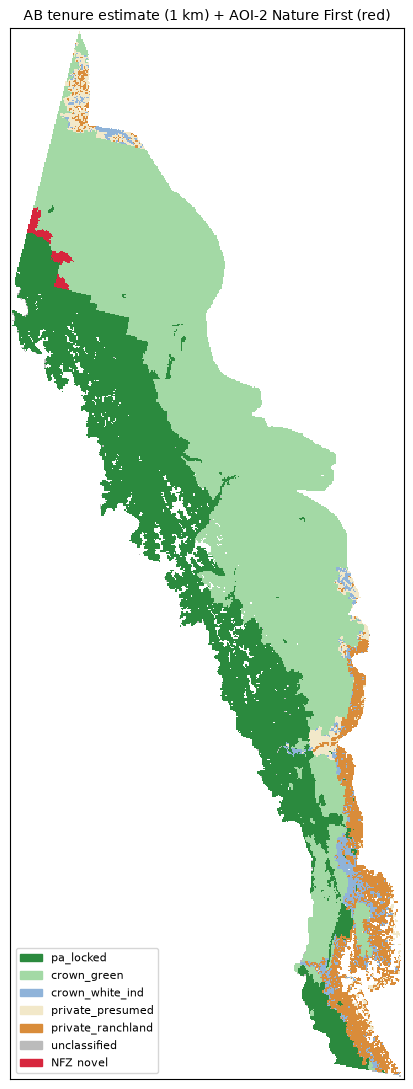

In [10]:
# ---- figure: tenure classes + NFZ outline ----------------------------------------------------------------
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
img = np.where(cls == 255, np.nan, cls).astype("float32")[R0:R1, C0:C1]
cmap = ListedColormap(["#2b8a3e", "#a3d9a5", "#8fb3d9", "#f2e8c9", "#d98c3a", "#bbbbbb"])
fig, ax = plt.subplots(figsize=(6.5, 11))
ax.imshow(img, cmap=cmap, vmin=1, vmax=6, interpolation="nearest")
nz = np.where(NFZ_NOVEL[R0:R1, C0:C1], 1.0, np.nan)
ax.imshow(nz, cmap=ListedColormap(["#d7263d"]), vmin=0, vmax=1, interpolation="nearest")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("AB tenure estimate (1 km) + AOI-2 Nature First (red)", fontsize=10)
ax.legend(handles=[Patch(color=c, label=l) for c, l in zip(
    ["#2b8a3e", "#a3d9a5", "#8fb3d9", "#f2e8c9", "#d98c3a", "#bbbbbb", "#d7263d"],
    ["pa_locked", "crown_green", "crown_white_ind", "private_presumed", "private_ranchland", "unclassified", "NFZ novel"])],
    loc="lower left", fontsize=8)
fig.tight_layout(); fig.savefig(FIGS / "ab_tenure_classes.png", dpi=180)
print("wrote", (FIGS / "ab_tenure_classes.png").relative_to(ROOT))

## → next

Enter the tenure shares, the ranch-fraction seam, AOI-2's novel area, and the distance-band null in
`spec/results_log.md` (R2.8–R2.10) in this session. Then `04_ab0_arms` (R).